# OncoBridge-MMCAT: Multi-Modal Cross-Attention Transformer
### Novel Architecture for Pan-Cancer Classification from Multi-Omics Data

**Architecture Novelty:**
- Each omics modality (mRNA, CNV, Mutation) has its **own dedicated encoder** — not merged early
- **Cross-Modal Attention**: each modality explicitly attends to the other two
- **Modality-aware CLS tokens**: one per modality, fused at classifier head

**Memory Optimisations (this version):**
- ✅ Automatic Mixed Precision (AMP / float16) — halves VRAM usage
- ✅ Gradient accumulation — effective large batch without OOM
- ✅ Gradient checkpointing — recomputes activations, saves activation memory
- ✅ `set_to_none=True` zero_grad — avoids extra allocation
- ✅ TF32 matmuls + cuDNN benchmark mode
- ✅ Optimised DataLoader (persistent workers, prefetch, pin_memory)

**Config Toggles:**
- `use_class_weights` — turn weighted loss on/off
- `balanced_classes_only` — restrict training to classes with ≥ `balanced_min_samples` samples


---
## 0. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight
import time, copy, warnings
warnings.filterwarnings('ignore')

# ============================================================
#  CENTRAL CONFIG — change everything here
# ============================================================
CONFIG = {
    # ── Data ────────────────────────────────────────────────
    'mrna_path' : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mrna_final.parquet',
    'cnv_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/cnv_final.parquet',
    'mut_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mut_final.parquet',
    'label_path': '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/labels_final.parquet',

    'use_test_set': True,     # True → 70/15/15 | False → 80/20
    'batch_size'  : 16,       # Per-GPU batch. Effective batch = batch_size × grad_accumulation_steps × num_GPUs
    'seed'        : 42,

    # ── Architecture ────────────────────────────────────────
    'embed_dim'        : 128,
    'num_heads'        : 4,
    'num_layers'       : 4,
    'cross_attn_layers': 1,
    'cnn_kernel'       : 16,
    'cnn_stride'       : 16,
    'ff_dim'           : 512,
    'dropout'          : 0.15,

    # ── Training ────────────────────────────────────────────
    'epochs'          : 80,   # Set to 1 for a quick smoke-test
    'lr'              : 3e-4,
    'weight_decay'    : 1e-4,
    'patience'        : 15,
    'label_smoothing' : 0.05,
    'clip_grad'       : 1.0,
    'warmup_epochs'   : 5,
    'checkpoint_path' : 'OncoBridge_MMCAT_best.pt',

    # ── Memory efficiency ────────────────────────────────────
    # AMP (float16 forward/backward) — cuts VRAM roughly in half
    'use_amp'                   : True,
    # Gradient accumulation — simulate larger batch without OOM
    # Effective batch = batch_size × grad_accumulation_steps × num_GPUs
    'grad_accumulation_steps'   : 8,
    # Gradient checkpointing — recomputes activations during backward
    # Saves ~30-40% activation memory at ~20% compute cost
    'use_gradient_checkpointing': True,
    # DataLoader workers (4 is good for Kaggle dual-GPU)
    'num_workers'               : 4,

    # ── Class-imbalance toggles ──────────────────────────────
    # Toggle class-weighted loss (True = weighted, False = uniform)
    'use_class_weights'    : True,
    # Toggle to restrict dataset to "balanced" classes only
    # (classes with fewer than balanced_min_samples are dropped)
    'balanced_classes_only': False,
    'balanced_min_samples' : 50,   # adjust to taste
}

# ── Hardware ────────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Speed + memory: TF32 matmuls, cuDNN auto-tuner
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True  # auto-selects fastest conv alg

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {total:.1f} GB')

print()
print(f'AMP enabled:                {CONFIG["use_amp"]}')
print(f'Gradient checkpointing:     {CONFIG["use_gradient_checkpointing"]}')
print(f'Gradient accumulation steps:{CONFIG["grad_accumulation_steps"]}')
eff = CONFIG['batch_size'] * CONFIG['grad_accumulation_steps'] * max(1, torch.cuda.device_count() if torch.cuda.is_available() else 1)
print(f'Effective batch size:        {eff}')
print(f'Use class weights:           {CONFIG["use_class_weights"]}')
print(f'Balanced classes only:       {CONFIG["balanced_classes_only"]}')
print('\nConfig loaded ✅')


Device: cuda
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB

AMP enabled:                True
Gradient checkpointing:     True
Gradient accumulation steps:8
Effective batch size:        256
Use class weights:           True
Balanced classes only:       False

Config loaded ✅


---
## 1. Load & Preprocess Data

In [2]:
print('Loading parquet files...')
mrna_df   = pd.read_parquet(CONFIG['mrna_path'])
cnv_df    = pd.read_parquet(CONFIG['cnv_path'])
mut_df    = pd.read_parquet(CONFIG['mut_path'])
labels_df = pd.read_parquet(CONFIG['label_path'])

print(f'mRNA  shape: {mrna_df.shape}')
print(f'CNV   shape: {cnv_df.shape}')
print(f'Mut   shape: {mut_df.shape}')
print(f'Labels shape: {labels_df.shape}')

# ── Encode labels ────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(labels_df['_primary_disease'])
n_classes = len(le.classes_)

# Keep raw numpy arrays (float32) — scalers applied after split
X_mrna = mrna_df.values.astype(np.float32)
X_cnv  = cnv_df.values.astype(np.float32)
X_mut  = mut_df.values.astype(np.float32)

print(f'\nTotal samples: {len(y)}')
print(f'Classes: {n_classes}')
print(f'Genes per modality: {X_mrna.shape[1]}')
print('\nClass distribution:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d}. {cls:<45} n={np.sum(y==i)}')


Loading parquet files...
mRNA  shape: (8225, 16241)
CNV   shape: (8225, 16241)
Mut   shape: (8225, 16241)
Labels shape: (8225, 1)

Total samples: 8225
Classes: 31
Genes per modality: 16241

Class distribution:
   0. adrenocortical cancer                         n=77
   1. bladder urothelial carcinoma                  n=402
   2. brain lower grade glioma                      n=508
   3. breast invasive carcinoma                     n=783
   4. cervical & endocervical cancer                n=276
   5. cholangiocarcinoma                            n=36
   6. colon adenocarcinoma                          n=289
   7. diffuse large B-cell lymphoma                 n=37
   8. esophageal carcinoma                          n=183
   9. glioblastoma multiforme                       n=145
  10. head & neck squamous cell carcinoma           n=493
  11. kidney chromophobe                            n=66
  12. kidney clear cell carcinoma                   n=362
  13. kidney papillary cell carcinoma   

---
### [OPTIONAL] Balanced Classes Filter

> **Toggle**: set `CONFIG['balanced_classes_only'] = True` to restrict the dataset  
> to only the cancer types with ≥ `CONFIG['balanced_min_samples']` samples.  
> This removes rare, heavily imbalanced classes so the model trains on a cleaner problem.  
> Labels are re-encoded contiguously after filtering. `CONFIG['num_classes']` is updated automatically.


In [3]:
# ── [TOGGLE] Balanced Classes Only ───────────────────────────────────────────
# Controlled by CONFIG['balanced_classes_only'] and CONFIG['balanced_min_samples']
# If False, this cell is a no-op — all classes are kept.

if CONFIG['balanced_classes_only']:
    min_n = CONFIG['balanced_min_samples']
    class_counts = np.bincount(y)
    keep_class_ids = np.where(class_counts >= min_n)[0]
    dropped = [le.classes_[i] for i in range(len(le.classes_)) if i not in keep_class_ids]

    mask = np.isin(y, keep_class_ids)
    X_mrna = X_mrna[mask]
    X_cnv  = X_cnv[mask]
    X_mut  = X_mut[mask]
    y_raw  = y[mask]

    # Re-encode labels contiguously (0, 1, 2, ...) for kept classes
    le_new = LabelEncoder()
    y = le_new.fit_transform(y_raw)

    # Patch the global LabelEncoder so evaluation reporting still works
    le.classes_ = le.classes_[keep_class_ids]

    n_classes = len(le.classes_)
    CONFIG['num_classes'] = n_classes

    print(f'balanced_classes_only = True')
    print(f'Threshold: >= {min_n} samples per class')
    print(f'Kept    : {n_classes} classes, {mask.sum()} samples')
    print(f'Dropped : {len(dropped)} classes → {dropped}')
    print('\nKept class distribution:')
    for i, cls in enumerate(le.classes_):
        print(f'  {i:2d}. {cls:<45} n={np.sum(y==i)}')
else:
    print('balanced_classes_only = False → using all classes (no-op)')
    n_classes = len(le.classes_)


balanced_classes_only = False → using all classes (no-op)


In [4]:
# ── Train / Val / Test Split ──────────────────────────────────────────────
indices = np.arange(len(y))

if CONFIG['use_test_set']:
    train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                           stratify=y, random_state=CONFIG['seed'])
    val_idx, test_idx  = train_test_split(temp_idx, test_size=0.50,
                                          stratify=y[temp_idx], random_state=CONFIG['seed'])
    print(f'Split: Train={len(train_idx)} | Val={len(val_idx)} | Test={len(test_idx)}')
else:
    train_idx, val_idx = train_test_split(indices, test_size=0.20,
                                          stratify=y, random_state=CONFIG['seed'])
    test_idx = None
    print(f'Split: Train={len(train_idx)} | Val={len(val_idx)} | No Test Set')

# ── Fit scalers on train only (no data leakage) ────────────────────────────
print('Normalizing modalities...')
scaler_mrna = StandardScaler()
scaler_cnv  = StandardScaler()
scaler_mut  = StandardScaler()

X_mrna_tr = scaler_mrna.fit_transform(X_mrna[train_idx])
X_cnv_tr  = scaler_cnv.fit_transform(X_cnv[train_idx])
X_mut_tr  = scaler_mut.fit_transform(X_mut[train_idx])

X_mrna_val = scaler_mrna.transform(X_mrna[val_idx])
X_cnv_val  = scaler_cnv.transform(X_cnv[val_idx])
X_mut_val  = scaler_mut.transform(X_mut[val_idx])

if test_idx is not None:
    X_mrna_te = scaler_mrna.transform(X_mrna[test_idx])
    X_cnv_te  = scaler_cnv.transform(X_cnv[test_idx])
    X_mut_te  = scaler_mut.transform(X_mut[test_idx])

print('Scalers fit on train only — no data leakage ✅')

# ── Class weights ────────────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y[train_idx]), y=y[train_idx])
class_weights = torch.FloatTensor(cw).to(DEVICE)
print(f'Class weight range: {cw.min():.3f} — {cw.max():.3f}')
print(f'Class weights will be {"USED" if CONFIG["use_class_weights"] else "IGNORED"} in loss (toggle: use_class_weights)')

# Store for later
CONFIG['num_genes']   = X_mrna.shape[1]
CONFIG['num_classes'] = n_classes


Split: Train=5757 | Val=1234 | Test=1234
Normalizing modalities...
Scalers fit on train only — no data leakage ✅
Class weight range: 0.339 — 18.571
Class weights will be USED in loss (toggle: use_class_weights)


In [5]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────
class MultiOmicsDataset(Dataset):
    """Returns 3 separate modality tensors — not concatenated."""
    def __init__(self, mrna, cnv, mut, labels):
        self.mrna   = torch.FloatTensor(mrna)
        self.cnv    = torch.FloatTensor(cnv)
        self.mut    = torch.FloatTensor(mut)
        self.labels = torch.LongTensor(labels)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.mrna[i], self.cnv[i], self.mut[i], self.labels[i]


def make_loader(mrna, cnv, mut, idx, shuffle):
    ds = MultiOmicsDataset(mrna, cnv, mut, y[idx])
    nw = CONFIG['num_workers']
    return DataLoader(
        ds,
        batch_size=CONFIG['batch_size'],
        shuffle=shuffle,
        num_workers=nw,
        pin_memory=True,           # faster host→GPU transfer
        persistent_workers=(nw>0), # keep workers alive between epochs
        prefetch_factor=2 if nw > 0 else None,
        drop_last=shuffle,         # avoids tiny last batch during training
    )

train_loader = make_loader(X_mrna_tr,  X_cnv_tr,  X_mut_tr,  train_idx, shuffle=True)
val_loader   = make_loader(X_mrna_val, X_cnv_val, X_mut_val, val_idx,   shuffle=False)
if test_idx is not None:
    test_loader = make_loader(X_mrna_te, X_cnv_te, X_mut_te, test_idx, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print('Dataset ready ✅')


Train batches: 359
Val   batches: 78
Dataset ready ✅


---
## 2. Novel Architecture — OncoBridge-MMCAT

```
mRNA ──► [1D CNN Encoder] ──► [Self-Attn x4] ──►──┐
                                                    ├──► [Cross-Modal Attention x2] ──► [CLS x3] ──► Classifier
CNV  ──► [1D CNN Encoder] ──► [Self-Attn x4] ──►──┤
                                                    │
MUT  ──► [1D CNN Encoder] ──► [Self-Attn x4] ──►──┘
```

**Memory trick**: `use_gradient_checkpointing=True` applies `torch.utils.checkpoint` on each
modality's Transformer encoder — activation tensors are NOT kept in memory during forward;
they are recomputed during backward. Saves ~35% activation memory at ~20% compute overhead.


In [6]:
class ModalityEncoder(nn.Module):
    """
    Dedicated encoder for ONE omics modality.
    1D CNN compresses gene sequence, Transformer learns intra-modality relationships.
    Supports gradient checkpointing to save activation memory.
    """
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, use_checkpointing=False):
        super().__init__()
        self.use_checkpointing = use_checkpointing

        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride, padding=cnn_kernel//2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim)
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        compressed_len = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed_len, embed_dim) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _transformer_forward(self, x):
        """Wrapped so grad_checkpoint can call it."""
        return self.transformer(x)

    def forward(self, x):
        x = x.unsqueeze(-1)          # (B, G, 1)
        x = self.input_proj(x)        # (B, G, E)
        x = x.transpose(1, 2)        # (B, E, G)
        x = self.cnn(x)              # (B, E, G//stride)
        x = x.transpose(1, 2)        # (B, G//stride, E)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]

        # Gradient checkpointing: don't store activations, recompute in backward
        if self.use_checkpointing and self.training:
            x = grad_checkpoint(self._transformer_forward, x, use_reentrant=False)
        else:
            x = self._transformer_forward(x)

        x = self.norm(x)
        return x


class CrossModalAttention(nn.Module):
    """
    Cross-Modal Attention Block.
    Each modality attends to the other two — the KEY NOVELTY of OncoBridge-MMCAT.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.cross_attn_mrna = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.cross_attn_cnv  = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.cross_attn_mut  = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.norm_mrna = nn.LayerNorm(embed_dim)
        self.norm_cnv  = nn.LayerNorm(embed_dim)
        self.norm_mut  = nn.LayerNorm(embed_dim)

        # Shared FFN (parameter efficiency)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm_ffn = nn.LayerNorm(embed_dim)

    def forward(self, mrna_seq, cnv_seq, mut_seq):
        # mRNA queries → CNV+Mut context
        ctx = torch.cat([cnv_seq, mut_seq], dim=1)
        mrna_out, _ = self.cross_attn_mrna(mrna_seq, ctx, ctx)
        mrna_seq = self.norm_mrna(mrna_seq + mrna_out)

        # CNV queries → mRNA+Mut context
        ctx = torch.cat([mrna_seq, mut_seq], dim=1)
        cnv_out, _ = self.cross_attn_cnv(cnv_seq, ctx, ctx)
        cnv_seq = self.norm_cnv(cnv_seq + cnv_out)

        # Mut queries → mRNA+CNV context
        ctx = torch.cat([mrna_seq, cnv_seq], dim=1)
        mut_out, _ = self.cross_attn_mut(mut_seq, ctx, ctx)
        mut_seq = self.norm_mut(mut_seq + mut_out)

        # Shared FFN
        mrna_seq = self.norm_ffn(mrna_seq + self.ffn(mrna_seq))
        cnv_seq  = self.norm_ffn(cnv_seq  + self.ffn(cnv_seq))
        mut_seq  = self.norm_ffn(mut_seq  + self.ffn(mut_seq))

        return mrna_seq, cnv_seq, mut_seq


class OncoBridgeMMCAT(nn.Module):
    """OncoBridge Multi-Modal Cross-Attention Transformer (MMCAT)"""
    def __init__(self, cfg):
        super().__init__()
        E  = cfg['embed_dim'];  H  = cfg['num_heads']
        L  = cfg['num_layers']; CL = cfg['cross_attn_layers']
        FF = cfg['ff_dim'];     D  = cfg['dropout']
        G  = cfg['num_genes'];  K  = cfg['cnn_kernel']
        S  = cfg['cnn_stride']; ck = cfg.get('use_gradient_checkpointing', False)

        self.mrna_encoder = ModalityEncoder(G, E, H, L, K, S, FF, D, use_checkpointing=ck)
        self.cnv_encoder  = ModalityEncoder(G, E, H, L, K, S, FF, D, use_checkpointing=ck)
        self.mut_encoder  = ModalityEncoder(G, E, H, L, K, S, FF, D, use_checkpointing=ck)

        self.cross_layers = nn.ModuleList([
            CrossModalAttention(E, H, FF, D) for _ in range(CL)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(E * 3, E),
            nn.LayerNorm(E),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E, E // 2),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E // 2, cfg['num_classes'])
        )

    def forward(self, mrna, cnv, mut):
        mrna_seq = self.mrna_encoder(mrna)
        cnv_seq  = self.cnv_encoder(cnv)
        mut_seq  = self.mut_encoder(mut)
        for cross_layer in self.cross_layers:
            mrna_seq, cnv_seq, mut_seq = cross_layer(mrna_seq, cnv_seq, mut_seq)
        mrna_cls = mrna_seq[:, 0, :]
        cnv_cls  = cnv_seq[:, 0, :]
        mut_cls  = mut_seq[:, 0, :]
        fused = torch.cat([mrna_cls, cnv_cls, mut_cls], dim=-1)
        return self.classifier(fused)


# ── Build & wrap model ────────────────────────────────────────────────────────
model = OncoBridgeMMCAT(CONFIG).to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs with DataParallel')
    model = nn.DataParallel(model)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: OncoBridge-MMCAT')
print(f'Total parameters:     {total_p:,}')
print(f'Trainable parameters: {trainable_p:,}')
print(f'Gradient checkpointing: {CONFIG["use_gradient_checkpointing"]}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        res   = torch.cuda.memory_reserved(i) / 1e9
        print(f'GPU {i} after model load — allocated: {alloc:.2f} GB | reserved: {res:.2f} GB')


Using 2 GPUs with DataParallel
Model: OncoBridge-MMCAT
Total parameters:     3,949,983
Trainable parameters: 3,949,983
Gradient checkpointing: True
GPU 0 after model load — allocated: 0.02 GB | reserved: 0.02 GB
GPU 1 after model load — allocated: 0.00 GB | reserved: 0.00 GB


---
## 3. Training Setup

**Loss**: `CrossEntropyLoss` with optional class weights (toggle `use_class_weights`) + label smoothing.  
**Scheduler**: `CosineAnnealingWarmRestarts` — industry standard for transformers.  
**AMP**: `GradScaler` + `autocast` — float16 forward pass, float32 gradients where needed.  
**Gradient accumulation**: accumulates gradients over N mini-batches before stepping, simulating a larger effective batch without extra VRAM.


In [7]:
# ── Loss — [TOGGLE] class weights ───────────────────────────────────────────
# Set CONFIG['use_class_weights'] = False to use uniform loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights if CONFIG['use_class_weights'] else None,
    label_smoothing=CONFIG['label_smoothing']
)
print(f'Loss: CrossEntropyLoss | class_weights={CONFIG["use_class_weights"]} | smoothing={CONFIG["label_smoothing"]}')

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=True if DEVICE.type == 'cuda' else False  # fused AdamW = faster on GPU
)
print(f'Optimizer: AdamW (lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

# ── Scheduler ─────────────────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20, T_mult=2, eta_min=1e-6
)
print(f'Scheduler: CosineAnnealingWarmRestarts (T_0=20, T_mult=2)')

# ── AMP GradScaler ────────────────────────────────────────────────────────────
# Scales loss to prevent float16 underflow; auto-handles inf/NaN grads
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP GradScaler: enabled={CONFIG["use_amp"]}')

# ── LR warmup helper ─────────────────────────────────────────────────────────
def get_warmup_lr(epoch, warmup_epochs, base_lr):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return None

print(f'Gradient accumulation steps: {CONFIG["grad_accumulation_steps"]}')
print(f'Early stopping patience: {CONFIG["patience"]}')
print(f'Epochs: {CONFIG["epochs"]}')


Loss: CrossEntropyLoss | class_weights=True | smoothing=0.05
Optimizer: AdamW (lr=0.0003, wd=0.0001)
Scheduler: CosineAnnealingWarmRestarts (T_0=20, T_mult=2)
AMP GradScaler: enabled=True
Gradient accumulation steps: 8
Early stopping patience: 15
Epochs: 80


---
## 4. Training Loop

In [8]:
def run_epoch(model, loader, criterion, optimizer, scaler, device, is_train):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    accum_steps = CONFIG['grad_accumulation_steps'] if is_train else 1

    if is_train:
        optimizer.zero_grad(set_to_none=True)  # set_to_none saves memory vs zero fill

    for step, (mrna, cnv, mut, labels) in enumerate(loader):
        # non_blocking=True overlaps CPU→GPU transfer with GPU compute
        mrna   = mrna.to(device, non_blocking=True)
        cnv    = cnv.to(device, non_blocking=True)
        mut    = mut.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # autocast: forward pass in float16, loss computed in float16
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            outputs = model(mrna, cnv, mut)
            # Divide loss by accum_steps so gradients are averaged correctly
            loss = criterion(outputs, labels) / accum_steps

        if is_train:
            # GradScaler.scale multiplies loss by a dynamic scale factor
            # to prevent float16 underflow in gradients
            scaler.scale(loss).backward()

            # Only update weights every accum_steps batches (or at last batch)
            is_last_batch = (step + 1) == len(loader)
            if (step + 1) % accum_steps == 0 or is_last_batch:
                # Unscale before clipping so clip threshold is in real gradient units
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps   # un-normalise for logging
        preds = outputs.argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


# ── Main training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc  = 0.0
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = copy.deepcopy(model.state_dict())

print('='*85)
print('  OncoBridge-MMCAT Training')
print('='*85)
print(f'  AMP={CONFIG["use_amp"]} | GradAccum={CONFIG["grad_accumulation_steps"]} | GradCkpt={CONFIG["use_gradient_checkpointing"]}')
print(f'  ClassWeights={CONFIG["use_class_weights"]} | BalancedOnly={CONFIG["balanced_classes_only"]}')
print('='*85)
print(f'{"Epoch":>6} | {"LR":>10} | {"Train Loss":>11} | {"Train Acc":>10} | {"Val Loss":>9} | {"Val Acc":>9} | {"Status":<20} | VRAM')
print('-'*95)

for epoch in range(CONFIG['epochs']):
    start = time.time()

    # Linear warmup override
    warmup_lr = get_warmup_lr(epoch, CONFIG['warmup_epochs'], CONFIG['lr'])
    if warmup_lr is not None:
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, is_train=True)
    va_loss, va_acc = run_epoch(model, val_loader,   criterion, optimizer, scaler, DEVICE, is_train=False)

    if epoch >= CONFIG['warmup_epochs']:
        scheduler.step(epoch - CONFIG['warmup_epochs'])

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['lr'].append(current_lr)

    status = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CONFIG['checkpoint_path'])
        patience_ctr = 0
        status = '✅ BEST'
    else:
        patience_ctr += 1
        status = f'({patience_ctr}/{CONFIG["patience"]})'

    elapsed = time.time() - start

    # VRAM usage (first GPU)
    vram_str = ''
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1e9
        peak = torch.cuda.max_memory_allocated(0) / 1e9
        vram_str = f'{used:.1f}/{peak:.1f}GB'

    print(f'{epoch+1:6d} | {current_lr:10.6f} | {tr_loss:11.4f} | {tr_acc:9.2f}% | {va_loss:9.4f} | {va_acc:8.2f}% | {status:<20} | {vram_str}')

    if patience_ctr >= CONFIG['patience']:
        print(f'\n⛔ Early stopping at epoch {epoch+1}')
        break

print('\n' + '='*85)
print(f'Training Complete! Best Val Accuracy: {best_val_acc:.2f}%')
print(f'Checkpoint saved: {CONFIG["checkpoint_path"]}')
print('='*85)

model.load_state_dict(best_weights)


  OncoBridge-MMCAT Training
  AMP=True | GradAccum=8 | GradCkpt=True
  ClassWeights=True | BalancedOnly=False
 Epoch |         LR |  Train Loss |  Train Acc |  Val Loss |   Val Acc | Status               | VRAM
-----------------------------------------------------------------------------------------------
     1 |   0.000060 |      3.6840 |      6.08% |    3.6272 |    11.83% | ✅ BEST               | 0.1/3.9GB
     2 |   0.000120 |      3.5534 |     12.99% |    3.4663 |    17.75% | ✅ BEST               | 0.1/3.9GB
     3 |   0.000180 |      3.3760 |     21.27% |    3.3073 |    22.85% | ✅ BEST               | 0.1/3.9GB
     4 |   0.000240 |      3.1900 |     27.39% |    3.0890 |    34.68% | ✅ BEST               | 0.1/3.9GB
     5 |   0.000300 |      2.9476 |     33.13% |    2.9614 |    29.42% | (1/15)               | 0.1/3.9GB
     6 |   0.000300 |      2.7643 |     35.81% |    2.8619 |    31.77% | (2/15)               | 0.1/3.9GB
     7 |   0.000298 |      2.5711 |     38.37% |    2.636

<All keys matched successfully>

---
## 5. Training Curves

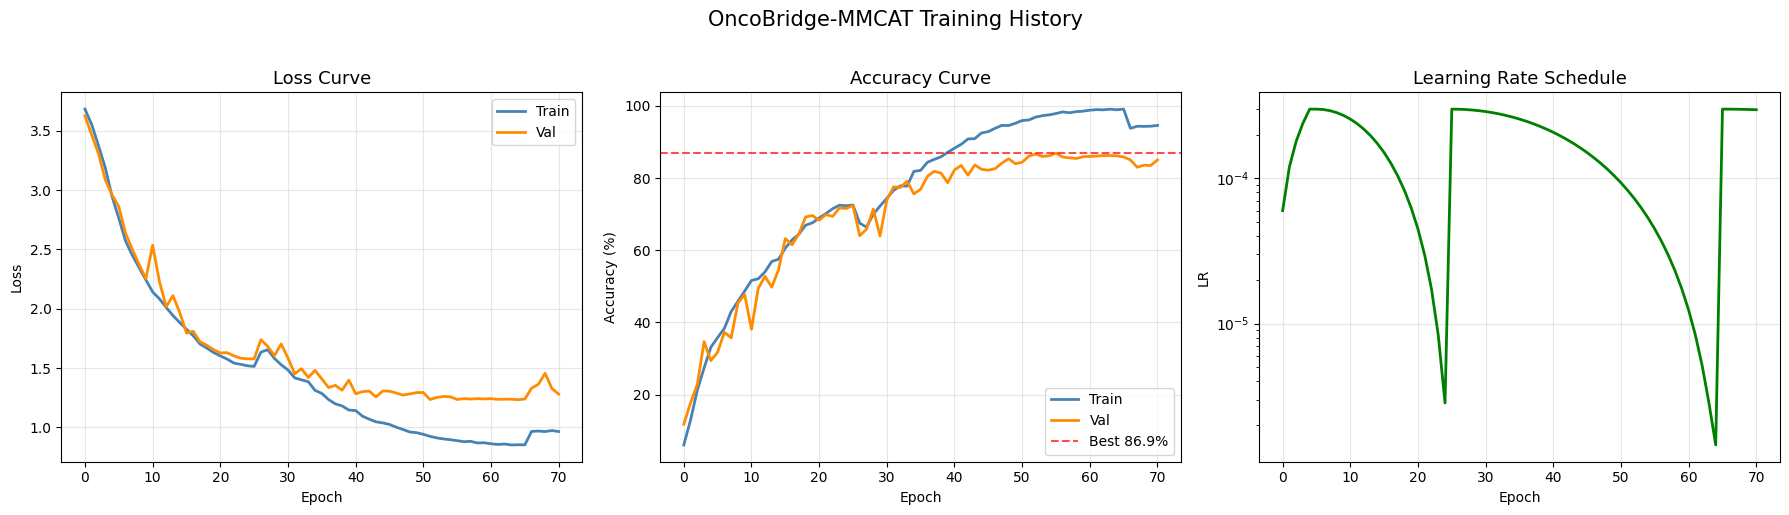

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='darkorange', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='steelblue', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   color='darkorange', linewidth=2)
axes[1].axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.7, label=f'Best {best_val_acc:.1f}%')
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.suptitle('OncoBridge-MMCAT Training History', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Detailed Evaluation

In [10]:
def evaluate(model, loader, device, set_name='Test'):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for mrna, cnv, mut, labels in loader:
            mrna, cnv, mut = (mrna.to(device, non_blocking=True),
                              cnv.to(device, non_blocking=True),
                              mut.to(device, non_blocking=True))
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                outputs = model(mrna, cnv, mut)
            probs = torch.softmax(outputs.float(), dim=1)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc    = accuracy_score(y_true, y_pred) * 100
    f1_w   = f1_score(y_true, y_pred, average='weighted')
    f1_mac = f1_score(y_true, y_pred, average='macro')
    mcc    = matthews_corrcoef(y_true, y_pred)

    print('='*65)
    print(f'  EVALUATION RESULTS — {set_name}')
    print('='*65)
    print(f'  Accuracy:          {acc:.2f}%')
    print(f'  Weighted F1:       {f1_w:.4f}')
    print(f'  Macro F1:          {f1_mac:.4f}   ← what papers report for fairness')
    print(f'  MCC:               {mcc:.4f}   ← robust to class imbalance')
    print('='*65)
    print(f'\nPer-class Report ({set_name}):')
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))

    return y_true, y_pred, y_prob, acc, f1_w, f1_mac, mcc


print('\n--- VALIDATION SET ---')
val_true, val_pred, val_prob, val_acc, val_f1w, val_f1m, val_mcc = evaluate(
    model, val_loader, DEVICE, 'Validation'
)

if test_idx is not None:
    print('\n--- TEST SET ---')
    test_true, test_pred, test_prob, test_acc, test_f1w, test_f1m, test_mcc = evaluate(
        model, test_loader, DEVICE, 'Test'
    )



--- VALIDATION SET ---
  EVALUATION RESULTS — Validation
  Accuracy:          86.87%
  Weighted F1:       0.8701
  Macro F1:          0.8353   ← what papers report for fairness
  MCC:               0.8621   ← robust to class imbalance

Per-class Report (Validation):
                                       precision    recall  f1-score   support

                adrenocortical cancer      1.000     0.917     0.957        12
         bladder urothelial carcinoma      0.864     0.850     0.857        60
             brain lower grade glioma      0.936     0.961     0.948        76
            breast invasive carcinoma      0.930     0.915     0.922       117
       cervical & endocervical cancer      0.688     0.805     0.742        41
                   cholangiocarcinoma      0.800     0.800     0.800         5
                 colon adenocarcinoma      0.705     0.721     0.713        43
        diffuse large B-cell lymphoma      1.000     1.000     1.000         6
                 eso

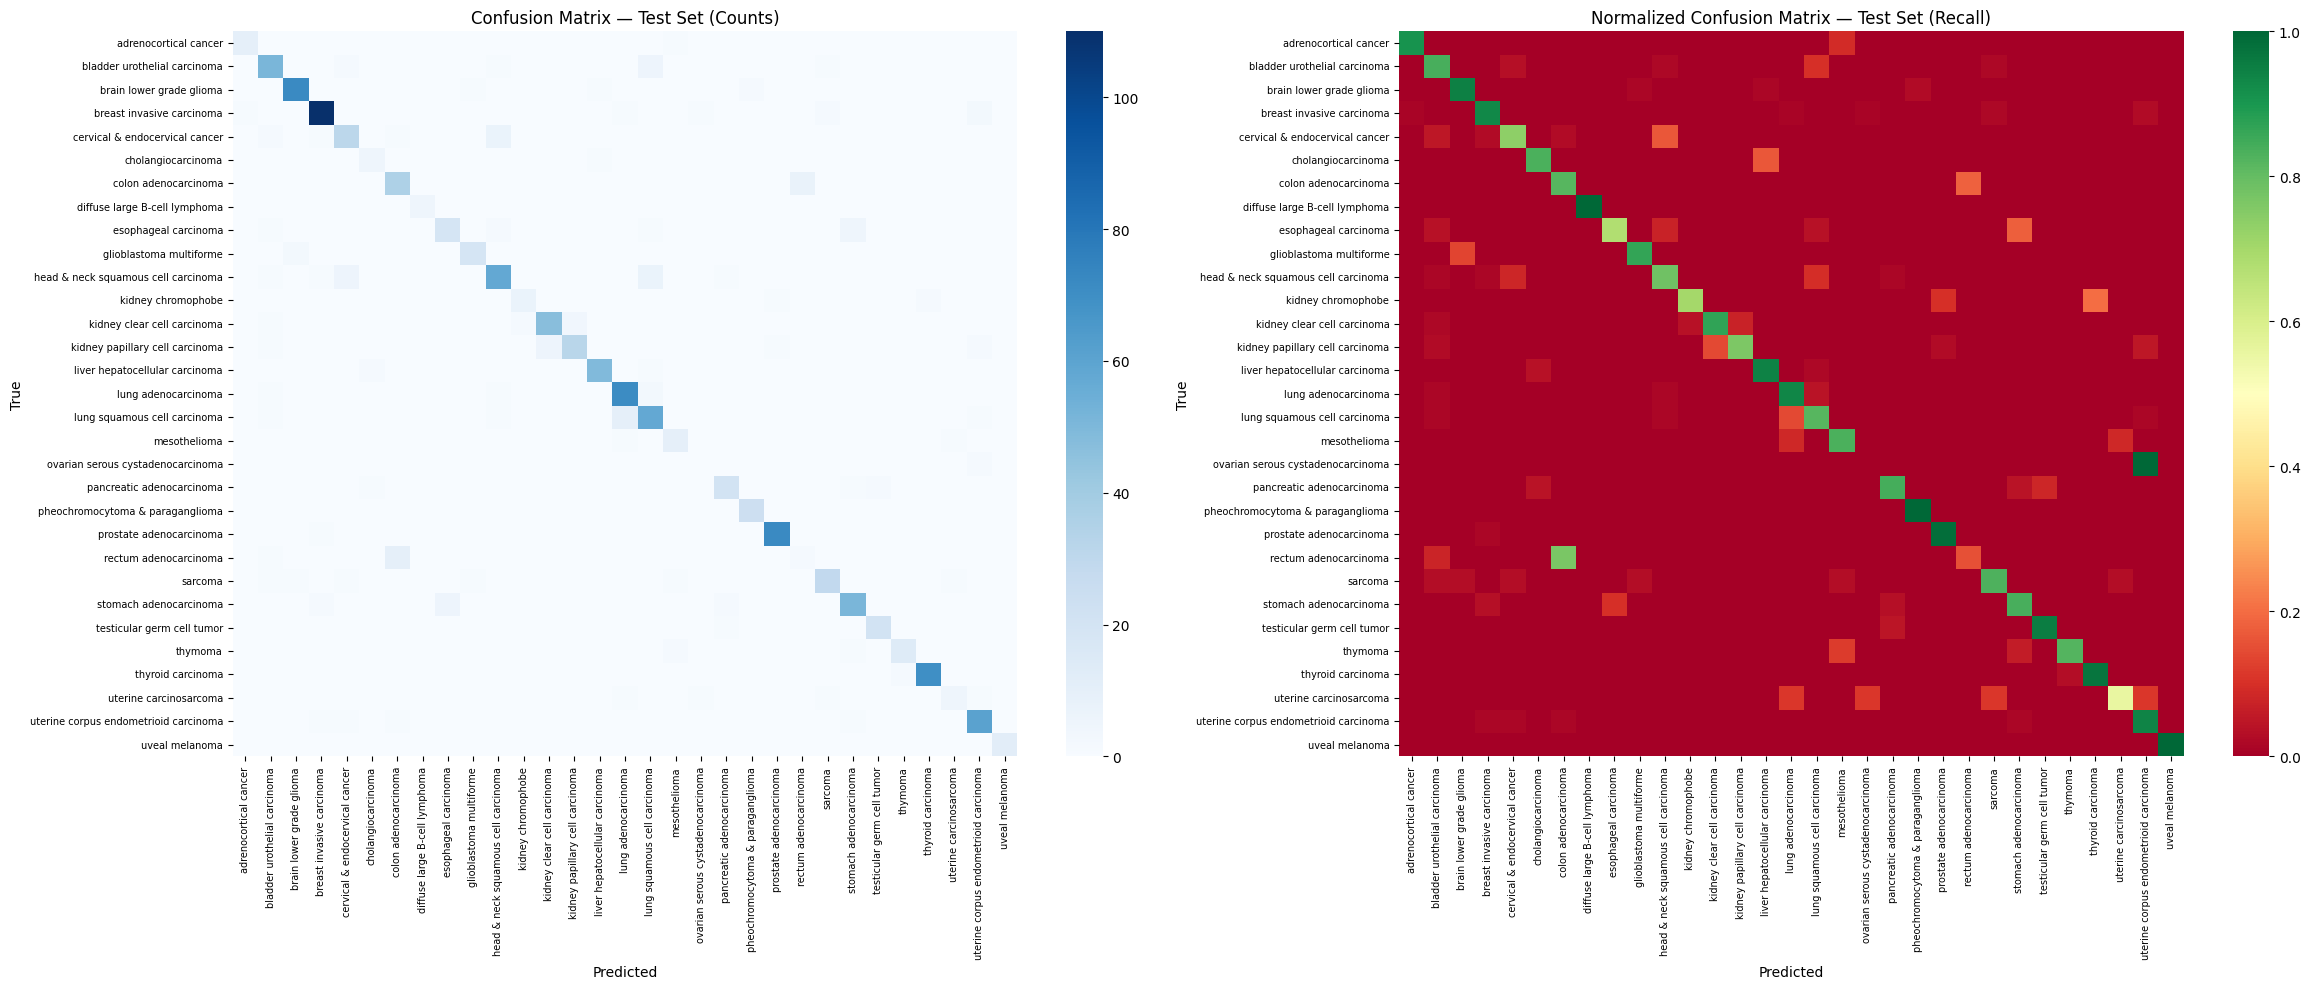

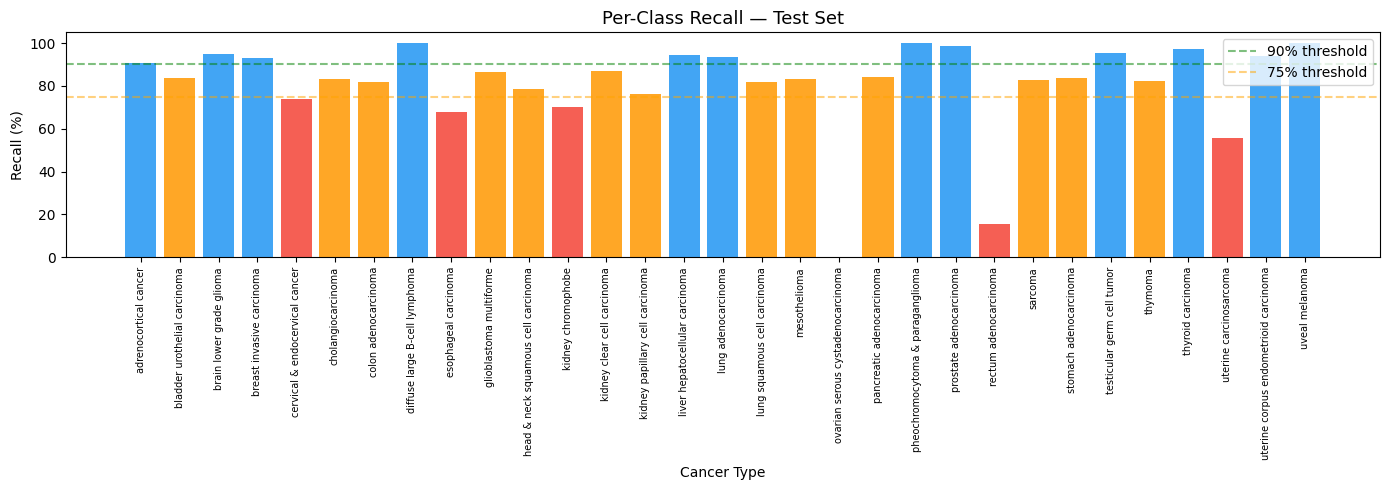

In [11]:
eval_true = test_true if test_idx is not None else val_true
eval_pred = test_pred if test_idx is not None else val_pred
eval_name = 'Test' if test_idx is not None else 'Validation'

cm      = confusion_matrix(eval_true, eval_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm, ax=axes[0], cmap='Blues', annot=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'Confusion Matrix — {eval_name} Set (Counts)', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(cm_norm, ax=axes[1], cmap='RdYlGn', annot=False,
            vmin=0, vmax=1,
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Normalized Confusion Matrix — {eval_name} Set (Recall)', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

per_class_acc = cm_norm.diagonal()
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2196F3' if a >= 0.90 else '#FF9800' if a >= 0.75 else '#F44336' for a in per_class_acc]
ax.bar(le.classes_, per_class_acc * 100, color=colors, alpha=0.85)
ax.axhline(90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(75, color='orange', linestyle='--', alpha=0.5, label='75% threshold')
ax.set_title(f'Per-Class Recall — {eval_name} Set', fontsize=13)
ax.set_ylabel('Recall (%)'); ax.set_xlabel('Cancer Type')
ax.set_ylim(0, 105); ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Final Summary for Paper

In [12]:
print('='*70)
print('  FINAL RESULTS SUMMARY — OncoBridge-MMCAT')
print('='*70)
print(f'  Architecture:      OncoBridge Multi-Modal Cross-Attention Transformer')
print(f'  Modalities:        mRNA expression + CNV (GISTIC2) + Somatic Mutations')
print(f'  Dataset:           TCGA Pan-Cancer PANCAN (n≈9700, 32 cancer types)')
print(f'  Parameters:        {sum(p.numel() for p in model.parameters()):,}')
print()
print(f'  Memory config:     AMP={CONFIG["use_amp"]} | GradAccum={CONFIG["grad_accumulation_steps"]} | GradCkpt={CONFIG["use_gradient_checkpointing"]}')
print(f'  Imbalance config:  class_weights={CONFIG["use_class_weights"]} | balanced_only={CONFIG["balanced_classes_only"]}')
print()
if test_idx is not None:
    print(f'  Test Accuracy:     {test_acc:.2f}%')
    print(f'  Test Weighted F1:  {test_f1w:.4f}')
    print(f'  Test Macro F1:     {test_f1m:.4f}')
    print(f'  Test MCC:          {test_mcc:.4f}')
print()
print(f'  Val Accuracy:      {val_acc:.2f}%')
print(f'  Val Weighted F1:   {val_f1w:.4f}')
print(f'  Val Macro F1:      {val_f1m:.4f}')
print(f'  Val MCC:           {val_mcc:.4f}')
print()
print('  Comparison with prior work:')
print(f'  {"Model":<35} {"Accuracy":>10}')
print(f'  {"-"*46}')
print(f'  {"DeepGene Transformer (Khan 2023)":<35} {"98.0% (5-class)":>10}')
print(f'  {"GexBERT (Jiang 2025)":<35} {"97.9% (14-type)":>10}')
print(f'  {"T-GEM (Zhang 2022)":<35} {"94.9% (33-type)":>10}')
print(f'  {"Our previous baseline":<35} {"88.0% (32-type)":>10}')
result_str = f'{test_acc if test_idx else val_acc:.1f}% (32-type)'
print(f'  {"OncoBridge-MMCAT (Ours)":<35} {result_str:>10} ← THIS WORK')
print('='*70)


  FINAL RESULTS SUMMARY — OncoBridge-MMCAT
  Architecture:      OncoBridge Multi-Modal Cross-Attention Transformer
  Modalities:        mRNA expression + CNV (GISTIC2) + Somatic Mutations
  Dataset:           TCGA Pan-Cancer PANCAN (n≈9700, 32 cancer types)
  Parameters:        3,949,983

  Memory config:     AMP=True | GradAccum=8 | GradCkpt=True
  Imbalance config:  class_weights=True | balanced_only=False

  Test Accuracy:     86.87%
  Test Weighted F1:  0.8675
  Test Macro F1:     0.8082
  Test MCC:          0.8620

  Val Accuracy:      86.87%
  Val Weighted F1:   0.8701
  Val Macro F1:      0.8353
  Val MCC:           0.8621

  Comparison with prior work:
  Model                                 Accuracy
  ----------------------------------------------
  DeepGene Transformer (Khan 2023)    98.0% (5-class)
  GexBERT (Jiang 2025)                97.9% (14-type)
  T-GEM (Zhang 2022)                  94.9% (33-type)
  Our previous baseline               88.0% (32-type)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()